In [34]:
# Conexión a la base de datos utilizando SQLAlchemy y psycopg2
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM hospital_performance_final", engine)

In [36]:
# Segmentación del hpi usando z-score
hpi_mean = df["hpi"].mean()
hpi_std = df["hpi"].std()
df["hpi_zscore"] = (df["hpi"] - hpi_mean) / hpi_std

df["hpi_class"] = pd.cut(
    df["hpi_zscore"],
    bins=[-float("inf"), -1.0, 1.0, float("inf")],
    labels=["low", "medium", "high"]
)

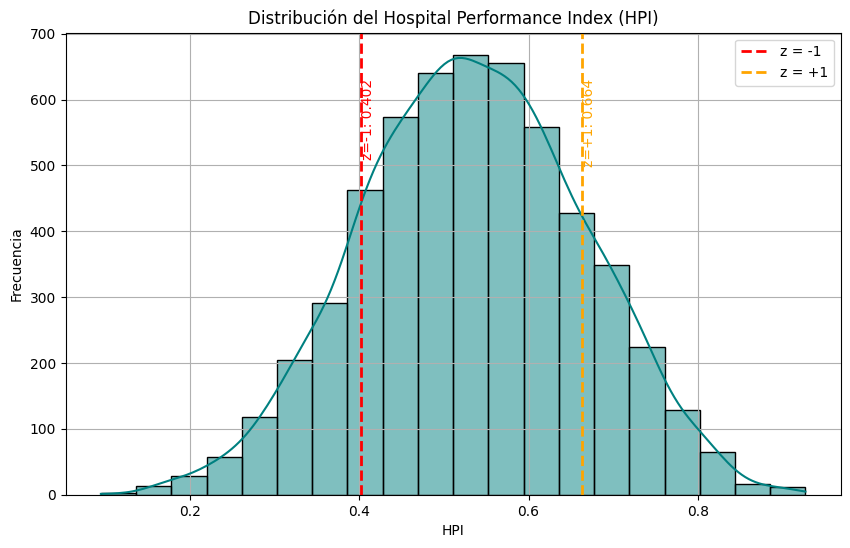

In [37]:
# Histograma del HPI con separación por z-score
plt.figure(figsize=(10, 6))
sns.histplot(df['hpi'], bins=20, kde=True, color='teal')

low_medium = hpi_mean - hpi_std
medium_high = hpi_mean + hpi_std

plt.axvline(low_medium, color='red', linestyle='--', linewidth=2, label='z = -1')
plt.axvline(medium_high, color='orange', linestyle='--', linewidth=2, label='z = +1')

ymax = plt.gca().get_ylim()[1]
plt.text(low_medium, ymax * 0.9, f'z=-1: {low_medium:.3f}', color='red', rotation=90, va='top')
plt.text(medium_high, ymax * 0.9, f'z=+1: {medium_high:.3f}', color='orange', rotation=90, va='top')

plt.legend()
plt.title('Distribución del Hospital Performance Index (HPI)')
plt.xlabel('HPI')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

In [38]:
# crear subconjuntos según la nueva clasificación por z-score
hpi_bajo = df[df['hpi_class']=='low'].copy()
hpi_medio = df[df['hpi_class']=='medium'].copy()
hpi_alto = df[df['hpi_class']=='high'].copy()

In [39]:
# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [40]:
hpi_bajo.shape[0]

877

In [41]:
hpi_medio.shape[0]

3688

In [42]:
hpi_alto.shape[0]

935

In [43]:
hpi_bajo.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,hpi_zscore
count,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,8.770000e+02,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000,877.000000
mean,2023.033067,762.440137,101.070696,10.725200,6.536602,205.571266,75.794755,408.079818,158.160775,0.001232,1564.729761,757.323831,206.525656,6.932953,410.824401,26642.890536,2078.929304,127190.751425,6.853259e+06,7.211745,2.756522,5.325462,7.593147,116.647662,20.083352,43.084379,1589.973888,0.039909,0.239940,0.244942,33.853763,771.811859,0.921561,0.262520,0.361425,0.471653,0.334024,-1.522239
std,0.830388,419.944329,56.465183,5.723936,1.451623,115.370481,42.852154,225.468585,85.005911,0.000437,856.385299,424.041393,112.777809,2.336131,227.041436,15160.280425,1494.552868,86851.579156,1.325744e+07,1.277174,1.316709,1.337075,1.933096,45.013597,11.206627,22.185184,856.415515,0.195857,0.326117,0.387424,46.622791,269.590091,1.387452,0.129906,0.179156,0.306416,0.056364,0.431165
min,2022.000000,52.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000501,53.000000,26.000000,6.000000,1.500000,10.000000,736.000000,100.000000,5052.000000,0.000000e+00,5.000000,0.510000,0.550000,1.310000,6.000000,1.100000,5.000000,54.333333,0.000000,0.003521,0.004306,0.428571,82.000000,0.038740,0.011000,0.023000,0.000000,0.095000,-3.350683
25%,2022.000000,391.000000,51.000000,6.000000,5.300000,102.000000,37.000000,217.000000,81.000000,0.000858,820.000000,406.000000,111.000000,5.300000,212.000000,12287.000000,654.000000,52098.000000,0.000000e+00,6.100000,1.570000,4.570000,6.430000,87.000000,10.300000,24.000000,846.666667,0.000000,0.068228,0.065488,9.900000,570.000000,0.323369,0.168000,0.218000,0.188000,0.303000,-1.759561
50%,2023.000000,767.000000,101.000000,11.000000,6.600000,209.000000,77.000000,407.000000,159.000000,0.001237,1585.000000,749.000000,206.000000,7.500000,415.000000,28021.000000,1871.000000,104205.000000,0.000000e+00,7.200000,2.750000,5.600000,8.080000,124.000000,20.000000,43.000000,1618.433333,0.000000,0.131892,0.130694,19.470588,769.000000,0.479420,0.249000,0.354000,0.444000,0.347000,-1.422978
75%,2024.000000,1121.000000,149.000000,16.000000,7.800000,305.000000,113.000000,605.000000,235.000000,0.001606,2286.000000,1133.000000,305.000000,8.900000,604.000000,40678.000000,3363.000000,203675.000000,5.337825e+06,8.300000,3.920000,6.410000,9.140000,154.000000,29.700000,63.000000,2324.633333,0.000000,0.254637,0.241576,35.800000,978.000000,0.937315,0.346000,0.494000,0.762000,0.379000,-1.178190
max,2024.000000,1499.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.001998,2997.000000,1500.000000,400.000000,10.000000,799.000000,49977.000000,4990.000000,299685.000000,4.990293e+07,9.500000,5.000000,7.000000,10.000000,180.000000,40.000000,80.000000,3028.400000,1.000000,2.821429,3.495935,391.000000,1448.000000,15.773006,0.710000,0.893000,0.995000,0.402000,-1.002248


In [44]:
hpi_medio.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,hpi_zscore
count,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.00000,3688.000000,3.688000e+03,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.00000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000,3688.000000
mean,2022.986171,778.478037,103.877711,10.528471,6.484816,204.447126,78.578633,406.507863,153.356020,0.001260,1494.520336,751.803959,202.217462,5.733460,409.840835,16294.019523,1588.12039,99861.077007,1.273802e+07,7.311822,2.760832,3.849528,5.513818,93.937636,20.650597,42.91974,1519.580468,0.040944,0.245579,0.269977,36.217231,764.311009,1.016790,0.491571,0.496877,0.680814,0.531005,-0.015407
std,0.819198,422.338485,57.351206,5.764453,1.430342,112.852825,42.042803,225.122256,84.981757,0.000433,847.047624,425.647044,114.609602,2.422111,229.674385,13070.023935,1482.99335,82113.649401,1.609035e+07,1.298469,1.305478,1.786071,2.473951,49.883280,11.315025,21.67433,847.131574,0.198186,0.362638,0.460699,54.079588,264.777448,1.590992,0.163612,0.195544,0.264187,0.071096,0.543855
min,2022.000000,50.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000501,50.000000,20.000000,5.000000,1.500000,10.000000,507.000000,100.00000,5068.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.00000,57.400000,0.000000,0.003340,0.003287,0.263158,96.000000,0.036312,0.018000,0.003000,0.000000,0.403000,-0.994599
25%,2022.000000,408.000000,54.000000,6.000000,5.300000,109.000000,42.000000,215.000000,78.000000,0.000886,753.750000,385.000000,103.000000,3.700000,214.000000,6573.000000,442.75000,38903.500000,0.000000e+00,6.200000,1.630000,2.330000,3.480000,53.000000,10.600000,25.00000,782.408333,0.000000,0.069405,0.070475,9.415789,566.000000,0.326978,0.382000,0.359750,0.513750,0.472750,-0.461037
50%,2023.000000,782.000000,105.000000,11.000000,6.500000,204.500000,78.000000,403.000000,152.000000,0.001266,1492.000000,743.000000,203.000000,5.700000,411.000000,11828.000000,749.00000,67269.000000,2.011124e+06,7.400000,2.780000,3.870000,5.520000,93.000000,21.100000,43.00000,1515.766667,0.000000,0.132107,0.135063,19.118056,767.000000,0.501084,0.489000,0.500000,0.771000,0.531000,-0.015447
75%,2024.000000,1141.000000,154.000000,16.000000,7.700000,302.000000,115.000000,600.000000,228.000000,0.001637,2219.000000,1123.250000,305.000000,7.800000,610.250000,24578.500000,2741.75000,153793.250000,2.501358e+07,8.400000,3.900000,5.360000,7.590000,137.000000,30.400000,62.00000,2247.425000,0.000000,0.254143,0.264195,37.125000,965.000000,0.969809,0.598250,0.636000,0.877250,0.590000,0.435881
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,3000.000000,1500.000000,400.000000,10.000000,800.000000,49960.000000,4993.00000,299953.000000,4.998359e+07,9.500000,5.000000,6.990000,10.000000,180.000000,40.000000,80.00000,3042.900000,1.000000,3.462963,5.705128,399.000000,1474.000000,19.616725,0.979000,0.994000,1.000000,0.663000,0.994304


In [45]:
hpi_alto.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,hpi_zscore
count,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.00000,935.000000,935.000000,9.350000e+02,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000
mean,2022.985027,791.212834,101.924064,10.536898,6.501604,201.493048,78.252406,409.719786,146.791444,0.001250,1541.155080,766.165775,204.530481,4.472513,399.489840,10136.33369,1148.730481,77976.248128,1.755367e+07,7.355936,2.771487,2.195529,3.261743,66.767914,20.138824,42.494118,1566.693939,0.042781,0.232197,0.244556,36.814339,758.004278,0.934127,0.743917,0.648665,0.805280,0.727615,1.488584
std,0.823757,421.170116,55.764202,5.810026,1.439199,112.988742,42.198197,232.087687,83.180091,0.000432,827.514357,429.163660,116.761323,2.203517,227.149989,8327.04421,1306.410725,71563.230790,1.669408e+07,1.305205,1.329782,1.343530,1.826195,45.277785,11.465983,21.772321,827.526780,0.202471,0.340134,0.429014,54.215475,264.960015,1.471740,0.122346,0.174707,0.168307,0.050737,0.388119
min,2022.000000,51.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000500,52.000000,22.000000,5.000000,1.500000,10.000000,502.00000,100.000000,5089.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.000000,69.033333,0.000000,0.004216,0.004573,0.350000,116.000000,0.076715,0.387000,0.126000,0.048000,0.664000,1.001953
25%,2022.000000,415.500000,54.000000,5.000000,5.200000,105.000000,42.000000,204.000000,74.000000,0.000889,861.500000,404.500000,105.000000,2.600000,200.500000,4474.00000,333.000000,31065.000000,0.000000e+00,6.200000,1.620000,1.080000,1.820000,27.000000,9.750000,24.000000,886.633333,0.000000,0.070295,0.067389,9.069444,558.000000,0.319925,0.654500,0.521000,0.753000,0.688000,1.185544
50%,2023.000000,794.000000,103.000000,10.000000,6.600000,200.000000,79.000000,410.000000,147.000000,0.001255,1567.000000,776.000000,207.000000,4.000000,394.000000,8341.00000,593.000000,54295.000000,1.365617e+07,7.400000,2.740000,1.860000,2.780000,60.000000,19.700000,42.000000,1591.900000,0.000000,0.128668,0.126130,19.250000,753.000000,0.483060,0.745000,0.657000,0.842000,0.716000,1.399734
75%,2024.000000,1175.500000,149.000000,16.000000,7.700000,298.000000,115.000000,621.500000,214.500000,0.001630,2238.500000,1133.500000,305.000000,6.000000,595.000000,12726.00000,1271.000000,79021.500000,3.313137e+07,8.500000,3.975000,3.040000,4.385000,100.000000,30.000000,62.000000,2257.983333,0.000000,0.241461,0.239770,37.777778,960.000000,0.837602,0.839000,0.783000,0.920000,0.755500,1.701894
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.001999,2999.000000,1500.000000,400.000000,10.000000,799.000000,47600.00000,4995.000000,299853.000000,4.991739e+07,9.500000,5.000000,6.890000,9.820000,179.000000,39.900000,80.000000,3034.833333,1.000000,3.344828,5.332738,390.000000,1447.000000,15.175202,0.995000,0.997000,1.000000,0.927000,3.013804


In [46]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

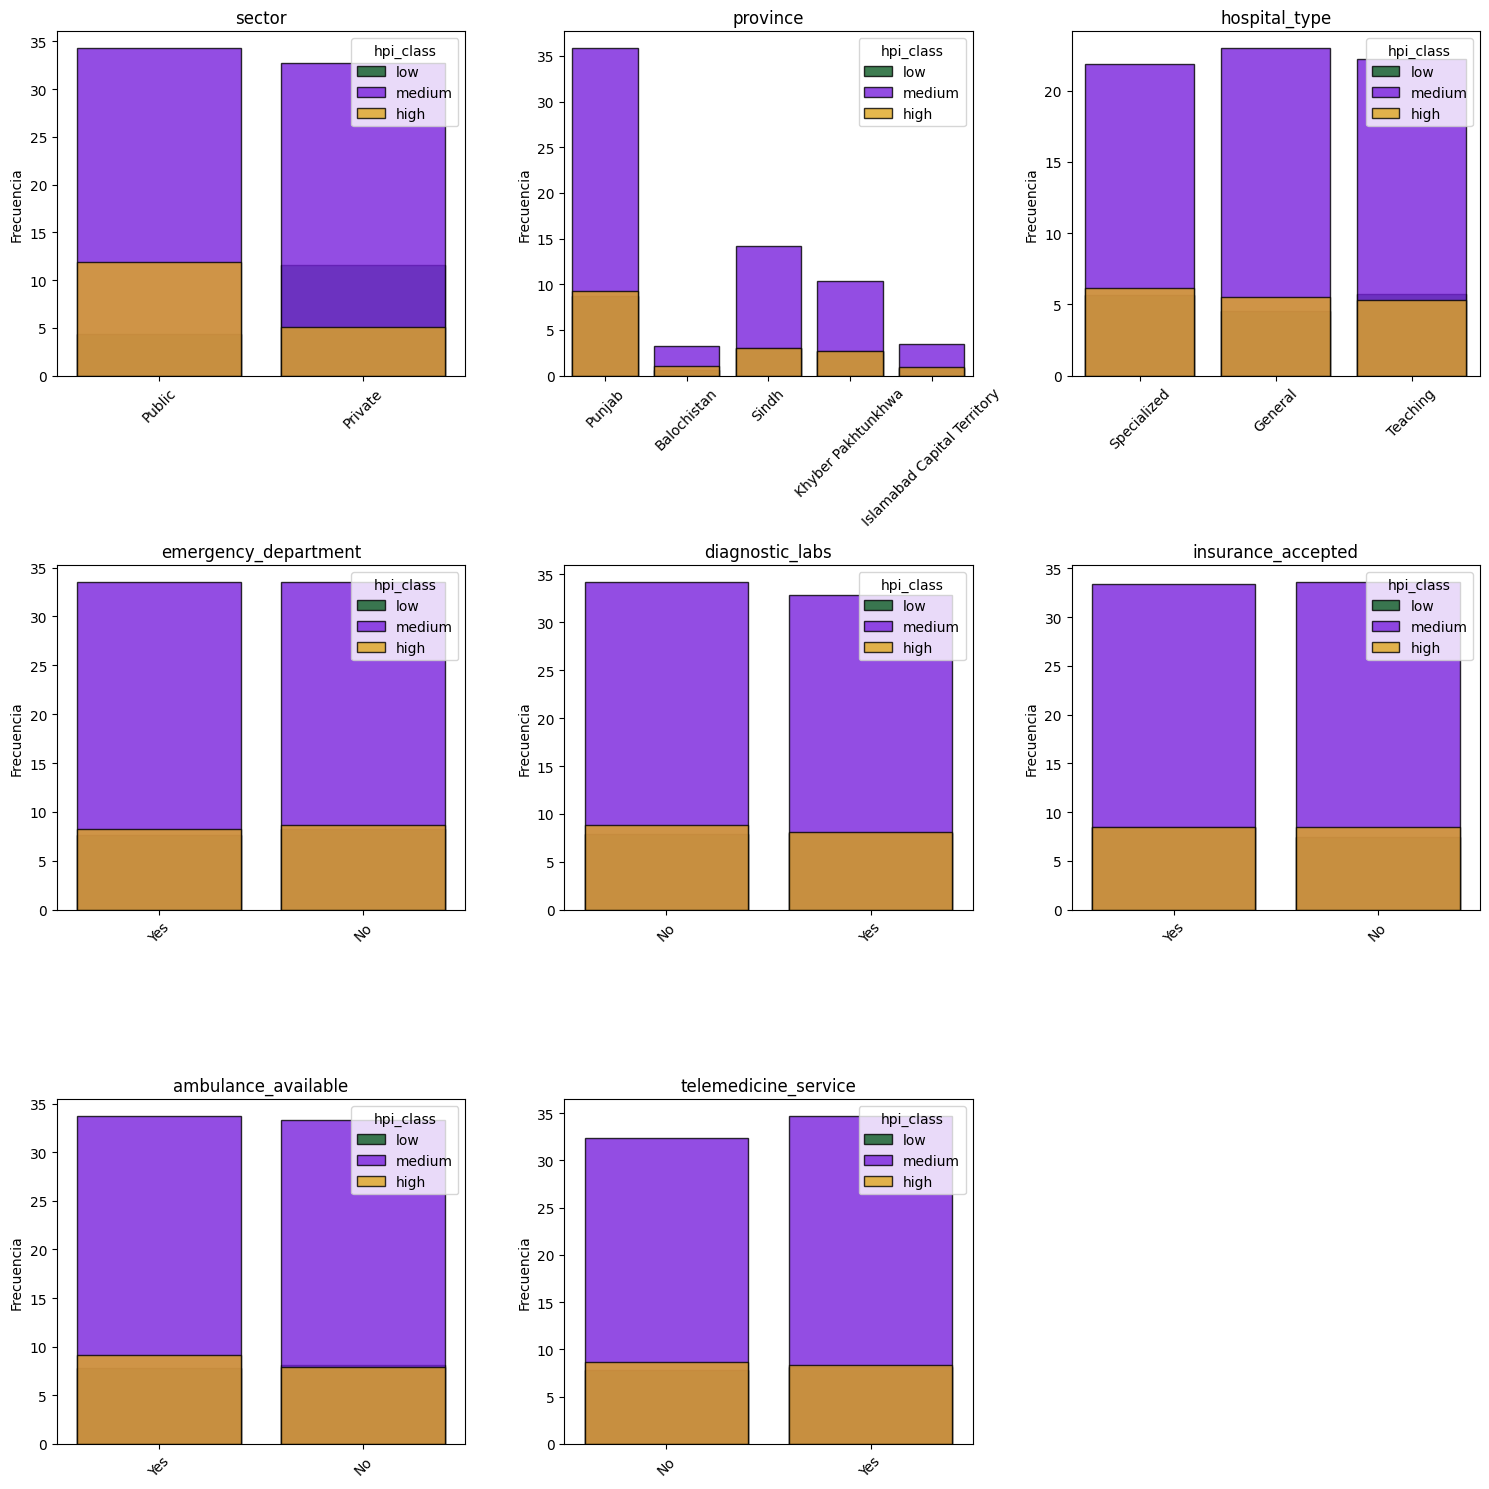

In [47]:
import math

# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 10  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]

    sns.countplot(
        data=df,
        x=col,
        hue="hpi_class",
        dodge=False,
        palette={"low": "#006920", "medium": "#7600fd", "high": "#ffb400"},
        edgecolor="black",
        ax=ax,
        stat="percent",
        alpha=0.8
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()